# 🌸 Clasificación vs Regresión — Dataset Iris
### Supervisado: Clasificación · No Supervisado: Clustering

El dataset Iris contiene 150 flores con 4 medidas morfológicas y la etiqueta de especie:

| Feature | Descripción |
|---------|-------------|
| `longitud_sepalo` | Longitud del sépalo (cm) |
| `ancho_sepalo` | Ancho del sépalo (cm) |
| `longitud_petalo` | Longitud del pétalo (cm) |
| `ancho_petalo` | Ancho del pétalo (cm) |
| `especie` | 0=Setosa, 1=Versicolor, 2=Virginica ← **TARGET** |

**Diferencia fundamental entre regresión y clasificación:**

| Tipo | Target | Ejemplo | Métricas |
|------|--------|---------|----------|
| **Regresión** | Número continuo | Precio de casa | RMSE, R² |
| **Clasificación** | Categoría discreta | Especie de flor | Accuracy, F1, Confusion Matrix |


In [1]:
# IMPORTS Y CONFIGURACIÓN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14

# CARGA DE DATOS
iris = load_iris(as_frame=True)
df = iris.frame.copy()

df.columns = ["longitud_sepalo", "ancho_sepalo",
               "longitud_petalo", "ancho_petalo", "especie"]

df["especie_nombre"] = df["especie"].map({
    0: "Setosa", 1: "Versicolor", 2: "Virginica"
})

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Clases: {df['especie_nombre'].unique()}")
print(f"Distribucion: {df['especie_nombre'].value_counts().to_dict()}")
df.head()

Dataset cargado: 150 filas x 6 columnas
Clases: ['Setosa' 'Versicolor' 'Virginica']
Distribucion: {'Setosa': 50, 'Versicolor': 50, 'Virginica': 50}


,longitud_sepalo,ancho_sepalo,longitud_petalo,ancho_petalo,especie,especie_nombre
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


---
## 🔍 Bloque 1: Conocer los Datos

La primera pregunta en **clasificación** es: ¿están las clases balanceadas?

- **Dataset balanceado**: misma cantidad de ejemplos por clase → las métricas son fiables.
- **Dataset desbalanceado**: si el 95% es clase A, un modelo que siempre prediga A tiene 95% de accuracy 
  sin aprender nada → la accuracy sola es engañosa.

En clasificación siempre miramos el `.describe()` **por clase** para ver si las features
tienen valores distintos según la categoría → eso es lo que el modelo aprenderá.


In [2]:
# EXPLORACIÓN BÁSICA
print("=== TIPOS Y NULOS ===")
print(df.dtypes)
print(f"\nNulos totales: {df.isnull().sum().sum()}")
print()
print("=== BALANCE DE CLASES ===")
print(df["especie_nombre"].value_counts())

=== TIPOS Y NULOS ===
longitud_sepalo    float64
ancho_sepalo       float64
longitud_petalo    float64
ancho_petalo       float64
especie              int32
especie_nombre      object
dtype: object

Nulos totales: 0

=== BALANCE DE CLASES ===
especie_nombre
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


In [ ]:
features = ["longitud_sepalo", "ancho_sepalo", "longitud_petalo", "ancho_petalo"]

---
## 📊 Bloque 2: Distribuciones por Clase — Violin Plots

En **regresión** miramos la distribución de cada feature a secas.
En **clasificación** las miramos **separadas por clase** para ver el poder discriminante:

- **Distribuciones separadas** → esa feature distingue bien las clases → será útil al modelo.
- **Distribuciones solapadas** → esa feature sola no distingue bien las clases.

El **violin plot** combina el boxplot (mediana, cuartiles) con la forma de la distribución (densidad).
`inner="box"` añade el boxplot dentro del violin para más información.


C:\Users\sorim\AppData\Local\Temp\ipykernel_21992\3432453507.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\sorim\AppData\Local\Temp\ipykernel_21992\3432453507.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\sorim\AppData\Local\Temp\ipykernel_21992\3432453507.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\sorim\AppData\Local\Temp\ipykernel_21992\3432453507.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

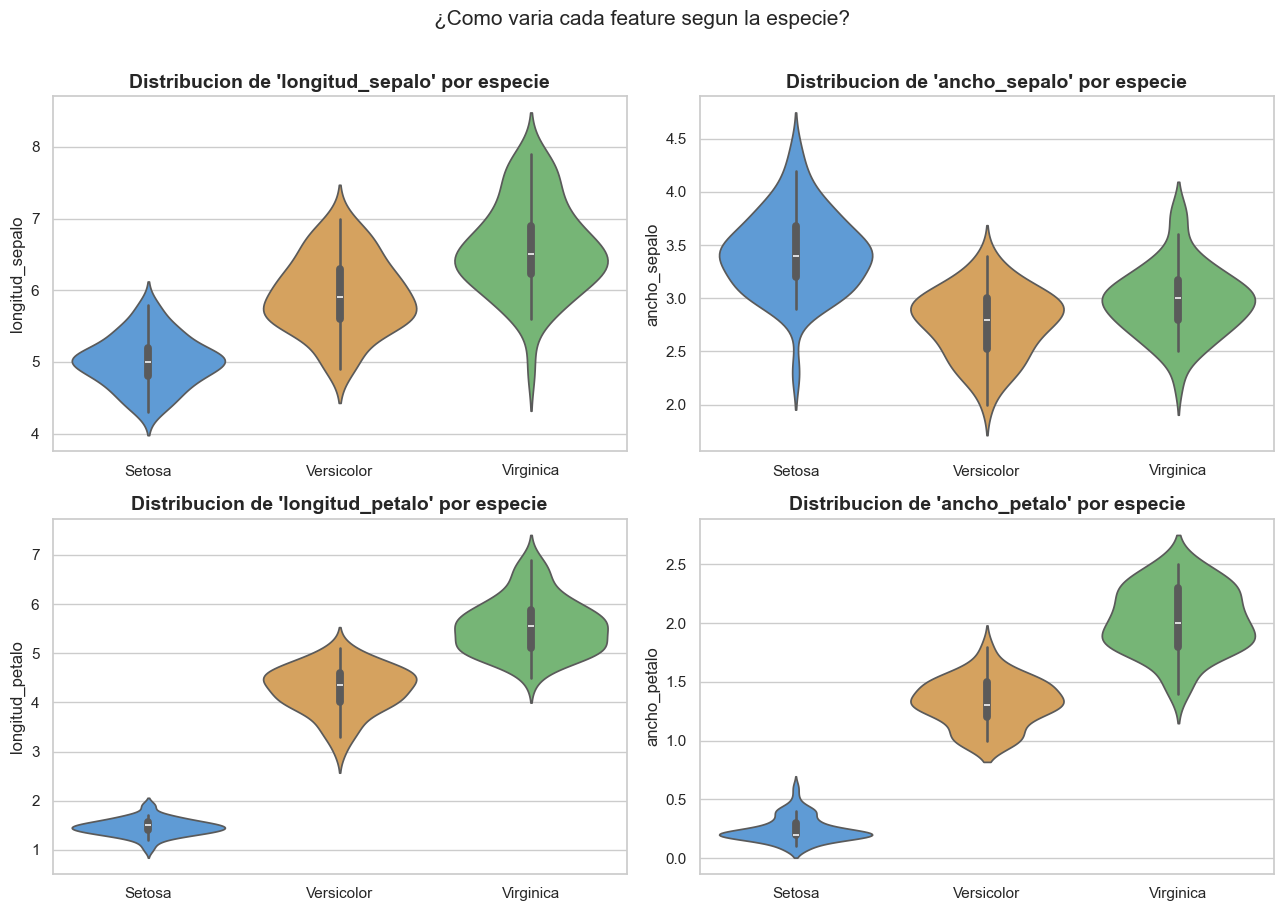

In [4]:
# VIOLIN PLOTS POR CLASE
colores  = {"Setosa": "#4C9BE8", "Versicolor": "#E8A44C", "Virginica": "#6CBF6C"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.violinplot(
        data=df, x="especie_nombre", y=feat,
        palette=colores, inner="box",
        ax=axes[i]
    )
    axes[i].set_title(f"Distribucion de '{feat}' por especie", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feat)

plt.suptitle("¿Como varia cada feature segun la especie?", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

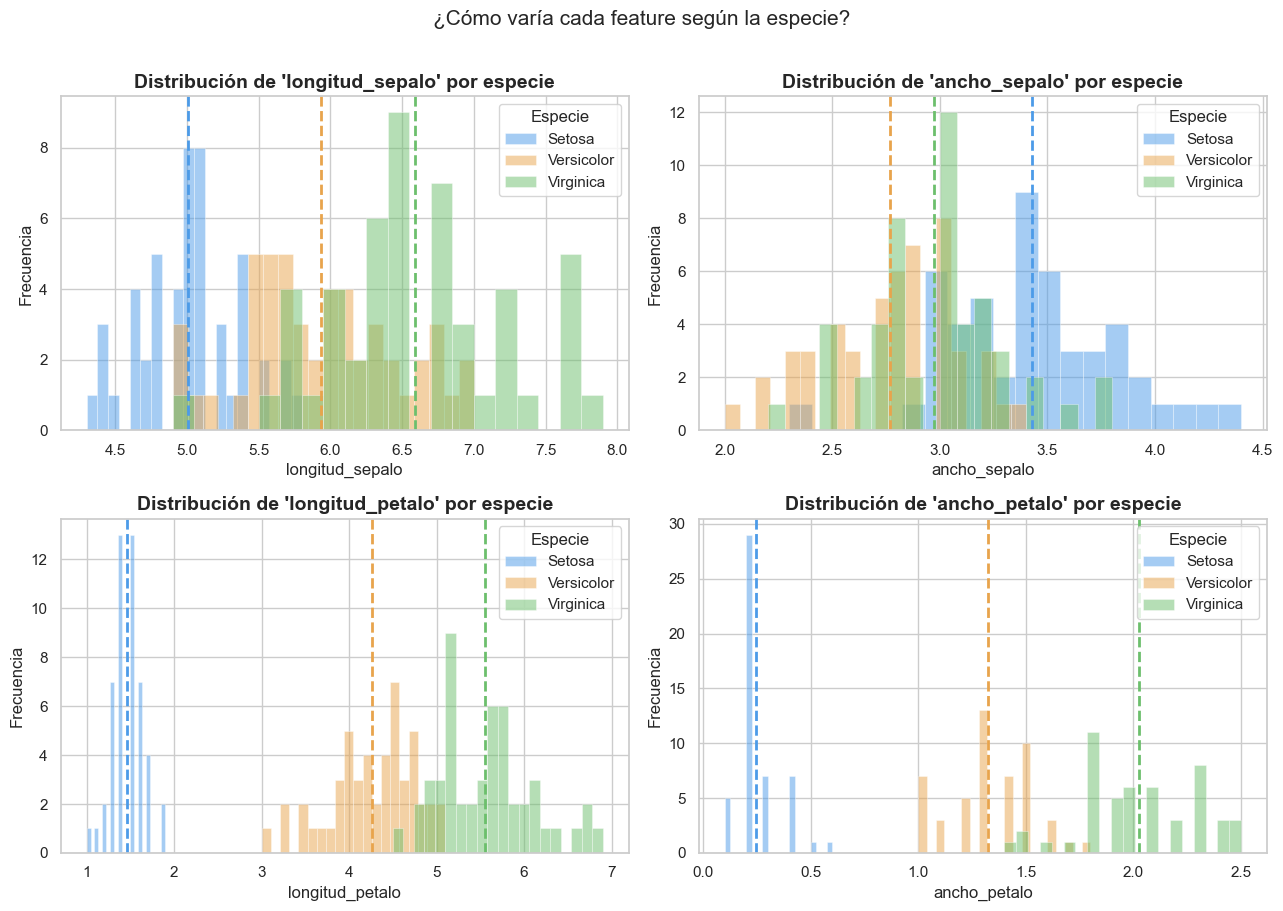

In [5]:
# HISTOGRAMAS SUPERPUESTOS POR CLASE
colores = {"Setosa": "#4C9BE8", "Versicolor": "#E8A44C", "Virginica": "#6CBF6C"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    for especie, color in colores.items():
        datos = df.loc[df["especie_nombre"] == especie, feat]
        axes[i].hist(
            datos,
            bins=20,
            color=color,
            alpha=0.5,           # transparencia para ver la superposición
            label=especie,
            edgecolor="white",
            linewidth=0.5
        )
        # línea vertical de la media de cada clase
        axes[i].axvline(
            datos.mean(),
            color=color,
            linewidth=2,
            linestyle="--"
        )

    axes[i].set_title(f"Distribución de '{feat}' por especie", fontweight="bold")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(title="Especie")

plt.suptitle("¿Cómo varía cada feature según la especie?", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

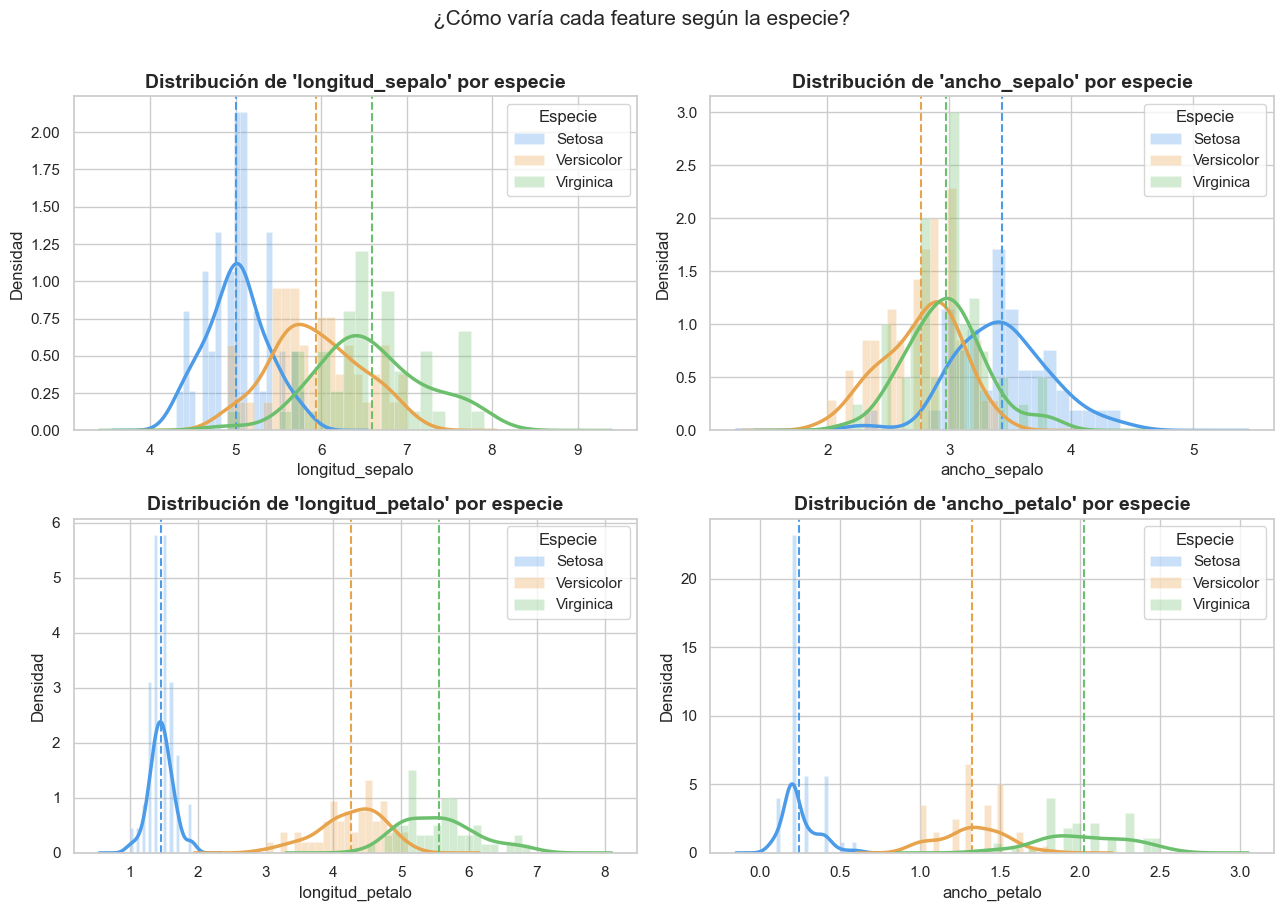

In [6]:
# HISTOGRAMAS SUPERPUESTOS + KDE POR CLASE
colores = {"Setosa": "#4C9BE8", "Versicolor": "#E8A44C", "Virginica": "#6CBF6C"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    for especie, color in colores.items():
        datos = df.loc[df["especie_nombre"] == especie, feat]

        axes[i].hist(
            datos,
            bins=20,
            color=color,
            alpha=0.3,           # más transparente para que la KDE destaque
            edgecolor="white",
            linewidth=0.5,
            density=True,        # normaliza a densidad para que escale igual que la KDE
            label=especie
        )

        # KDE encima del histograma, mismo color pero sólida
        datos.plot.kde(
            ax=axes[i],
            color=color,
            linewidth=2.5,
            label=""             # evita duplicar la leyenda
        )

        # media de cada clase
        axes[i].axvline(
            datos.mean(),
            color=color,
            linewidth=1.5,
            linestyle="--"
        )

    axes[i].set_title(f"Distribución de '{feat}' por especie", fontweight="bold")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Densidad")
    axes[i].legend(title="Especie")

plt.suptitle("¿Cómo varía cada feature según la especie?", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## 🔷 Bloque 5: Gráfico Comparativo Global — Pairplot por Clase

El **pairplot en clasificación** colorea los puntos por clase para ver de un vistazo qué pares 
de features separan mejor las tres especies.

- Diagonal: curvas de densidad (KDE) por clase → si las curvas no se solapan, esa feature discrimina bien.
- Celdas: scatter entre cada par → buscamos grupos de colores bien separados.

`corner=True` muestra solo el triángulo inferior para evitar la redundancia del triángulo superior.


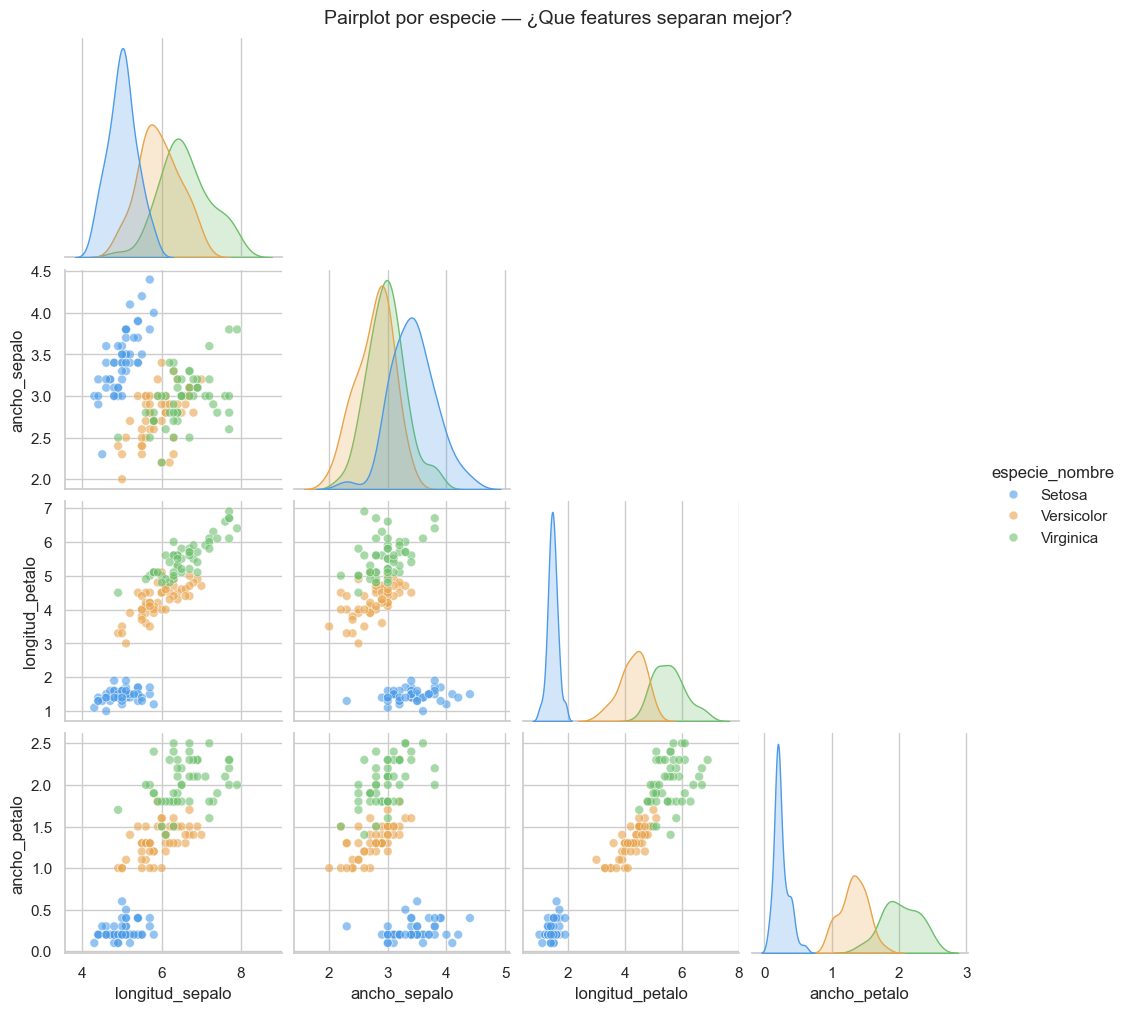

In [ ]:
# PAIRPLOT POR CLASE
df_plot = df[features + ["especie_nombre"]].copy()

pair_grid = sns.pairplot(
    df_plot,
    hue="especie_nombre",
    palette={"Setosa":"#4C9BE8","Versicolor":"#E8A44C","Virginica":"#6CBF6C"},
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 40},
    corner=True
)
pair_grid.figure.suptitle("Pairplot por especie — ¿Que features separan mejor?",
                           y=1.01, fontsize=14)
plt.show()


---
## 🔗 Bloque 3: Correlaciones entre Features

En clasificación el heatmap se usa principalmente para detectar **multicolinealidad** 
entre features (features que miden lo mismo, es decir, redundantes).

Si dos features tienen correlación muy alta (>0.9), una de ellas aporta poca información 
adicional y podría eliminarse para simplificar el modelo. Esto conecta con **PCA** 
(Análisis de Componentes Principales): si hay mucha correlación entre features, PCA puede 
condensarlas en menos dimensiones sin perder casi información.


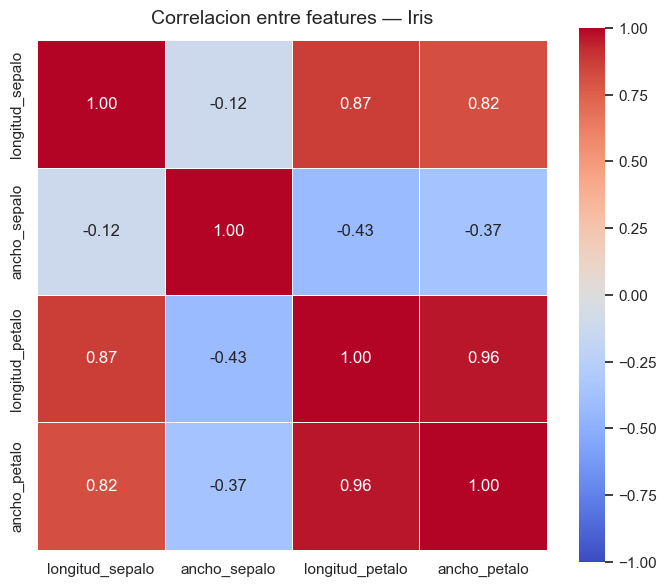

In [7]:
# HEATMAP DE CORRELACIÓN
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title("Correlacion entre features — Iris", fontsize=14, pad=12)
plt.tight_layout()
plt.show()


---
## 📈 Bloque 4: Relaciones entre Features — Scatter por Clase

En clasificación, el scatter muestra si las clases son **separables** en el espacio de features.

- **Grupos bien separados** (sin solapamiento) → el modelo tendrá fácil clasificar ahí.
- **Grupos solapados** → el modelo cometerá más errores en esa zona → habrá más confusión.

La **separabilidad lineal** significa que se podría trazar una línea recta para separar las clases.
Si no es linealmente separable, puede necesitarse un modelo más complejo.


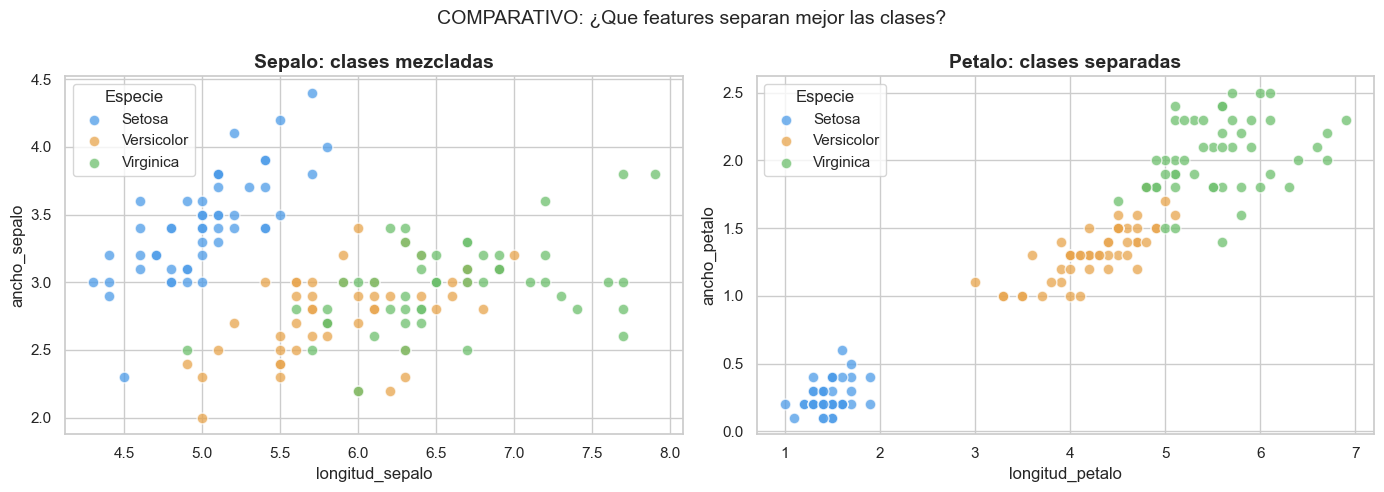

In [8]:
# SCATTER COMPARATIVO: SEPALO vs PETALO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_lista = ["#4C9BE8", "#E8A44C", "#6CBF6C"]

for ax, (feat_x, feat_y), titulo in zip(
    axes,
    [("longitud_sepalo", "ancho_sepalo"), ("longitud_petalo", "ancho_petalo")],
    ["Sepalo: clases mezcladas", "Petalo: clases separadas"]
):
    for clase, color in zip(["Setosa","Versicolor","Virginica"], colores_lista):
        mask = df["especie_nombre"] == clase
        ax.scatter(df.loc[mask, feat_x], df.loc[mask, feat_y],
                   color=color, label=clase, alpha=0.75, s=60, edgecolors="white")
    ax.set_xlabel(feat_x, fontsize=12)
    ax.set_ylabel(feat_y, fontsize=12)
    ax.set_title(titulo, fontweight="bold")
    ax.legend(title="Especie")

plt.suptitle("COMPARATIVO: ¿Que features separan mejor las clases?", fontsize=14)
plt.tight_layout()
plt.show()


---
## 🤖 Bloque 6: SUPERVISADO: ESTRATEGIA DE ELECCIÓN Y OPTIMIZACIÓN

### Métricas de clasificación:

| Métrica | Fórmula | Cuándo priorizarla |
|---------|---------|---------------------|
| **Accuracy** | Correctos / Total | Dataset balanceado |
| **Precision** | TP / (TP+FP) | FP caros (spam: no marcar email válido como spam) |
| **Recall** | TP / (TP+FN) | FN caros (médico: no perder un caso enfermo) |
| **F1** | 2·P·R / (P+R) | Balance entre Precision y Recall |

In [ ]:
# PREPARACIÓN: SPLIT + ESCALAR
X = df[features]
y = df["especie"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y      # conserva proporción de clases en train y test
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

Train: 120 muestras | Test: 30 muestras


### BASELINE CON CROSS-VALIDATION 

Antes de elegir un modelo, comparamos varios candidatos con CV en train.
> Regla: NUNCA tocamos X_test hasta tener el modelo final elegido.

#### ¿Por qué cross-validation y no un único split train/val?
Con un solo split, el resultado depende de qué datos cayeron en validación por azar.  
CV divide el train en K partes, entrena K veces y promedia → estimación más robusta.

In [ ]:
# BASELINE SUPERVISADO: CLASIFICACIÓN y REGRESIÓN

import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# ════════════════════════════════════════════════════════════════════════════
# CLASIFICACIÓN
# ════════════════════════════════════════════════════════════════════════════
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_clasificacion = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,    # no es un HP real, solo evita ConvergenceWarning
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,     # estabiliza predicciones sin disparar el tiempo -> NO HACE FALTA ESPECIFICARLO SI ES A 100 YA QUE ES POR DEFECTO
        max_depth=3,       
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,     
        learning_rate=0.1,    # default razonable: ni muy agresivo ni muy lento
                              # lr alto (>0.3) sobreajusta rápido
                              # lr bajo (<0.01) necesita muchos más árboles
        max_depth=3,          
        random_state=42,
        n_jobs=-1,
        verbosity=0           # silencia los logs de XGBoost
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,     # mismo criterio que XGBoost
        learning_rate=0.1,    # mismo criterio que XGBoost
        num_leaves=31,        # default de LightGBM, conservador
                              # equivale aproximadamente a max_depth=5 en level-wise
        random_state=42,
        n_jobs=-1,
        verbose=-1            # silencia los logs de LightGBM
    )
}

# EVALUACIÓN CLASIFICACIÓN
print("=" * 55)
print("BASELINE CLASIFICACIÓN")
print("=" * 55)
for nombre, modelo in modelos_clasificacion.items():
    scores = cross_val_score(modelo, X_train_sc, y_train, cv=cv_clf, scoring="accuracy")
    print(f"{nombre:<22} accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


# ════════════════════════════════════════════════════════════════════════════
# REGRESIÓN -> (EJEMPLO, NO EJECUTARLO)
# ════════════════════════════════════════════════════════════════════════════

modelos_regresion = {

    "Linear Regression": LinearRegression(
        n_jobs=-1
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,     # mismo criterio que clasificación
        max_depth=3,          # mismo criterio
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,     # mismo criterio
        learning_rate=0.1,    # mismo criterio
        max_depth=3,          # mismo criterio: boosting → árboles poco profundos
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=100,     # mismo criterio
        learning_rate=0.1,    # mismo criterio
        num_leaves=31,        # mismo criterio
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

#── EVALUACIÓN REGRESIÓN
print("\n" + "=" * 55)
print("BASELINE REGRESIÓN")
print("=" * 55)
for nombre, modelo in modelos_regresion.items():
    scores_r2   = cross_val_score(modelo, X_scaled, y, cv=5, scoring="r2")
    scores_rmse = cross_val_score(modelo, X_scaled, y, cv=5,
                                  scoring="neg_root_mean_squared_error")
    print(f"{nombre:<22} R²: {scores_r2.mean():.4f} ± {scores_r2.std():.4f} "
          f"| RMSE: {(-scores_rmse.mean()):.4f} ± {scores_rmse.std():.4f}")